# NYC Taxi Trip Duration - Inference & Predictions

Ce notebook charge le modèle et effectue des prédictions sur de nouveaux exemples.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys

# Add src to path
sys.path.insert(0, '..')

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 1. Charger le modèle

In [2]:
from src.model.inference import TaxiDurationPredictor
from pathlib import Path

# Initialiser le predictor
predictor = TaxiDurationPredictor(config_path='../configs/config.yaml')

# Corriger les chemins (relatifs au notebook)
predictor.trainer.processed_path = Path('..') / predictor.trainer.processed_path
predictor.trainer.model_dir = Path('..') / predictor.trainer.model_dir

# Charger le modèle
print("Chargement du modèle...")
try:
    predictor.load_model()
    print("✓ Modèle chargé avec succès!")
except FileNotFoundError:
    print("⚠️  Modèle non trouvé. Veuillez d'abord exécuter le notebook 02_model_training.ipynb")

Chargement du modèle...
Model loaded from ../models/taxi_model.pkl
Looking for metadata at: ../models/model_metadata.json (exists: True)
✓ Model metadata loaded (16 features)
✓ Modèle chargé avec succès!


## 2. Prédictions sur des exemples

Effectuons des prédictions sur des exemples réalistes de trajets en taxi.

In [3]:
# Exemples de trajets
samples = [
    {
        'pickup_datetime': '2016-03-14 17:24:55',
        'pickup_latitude': 40.7614,
        'pickup_longitude': -73.9776,
        'dropoff_latitude': 40.7489,
        'dropoff_longitude': -73.9680,
        'passenger_count': 1,
        'vendor_id': 1,
        'trip_duration': 0  # Placeholder - will be ignored
    },
    {
        'pickup_datetime': '2016-03-14 10:15:30',
        'pickup_latitude': 40.7505,
        'pickup_longitude': -73.9972,
        'dropoff_latitude': 40.7614,
        'dropoff_longitude': -73.9776,
        'passenger_count': 2,
        'vendor_id': 2,
        'trip_duration': 0
    },
    {
        'pickup_datetime': '2016-03-14 22:50:00',
        'pickup_latitude': 40.6501,
        'pickup_longitude': -73.9496,
        'dropoff_latitude': 40.7589,
        'dropoff_longitude': -73.9851,
        'passenger_count': 3,
        'vendor_id': 1,
        'trip_duration': 0
    },
    {
        'pickup_datetime': '2016-03-14 09:00:00',
        'pickup_latitude': 40.7582,
        'pickup_longitude': -73.9855,
        'dropoff_latitude': 40.7489,
        'dropoff_longitude': -73.9680,
        'passenger_count': 1,
        'vendor_id': 1,
        'trip_duration': 0
    }
]

# Faire les prédictions
print("\n" + "="*80)
print("PRÉDICTIONS DE DURÉE DE TRAJET")
print("="*80)

predictions = predictor.predict_batch(samples)

# Afficher les résultats
for i, (sample, pred) in enumerate(zip(samples, predictions), 1):
    print(f"\n[Sample {i}]")
    print(f"  Pickup Time:    {sample['pickup_datetime']}")
    print(f"  Pickup Coords:  ({sample['pickup_latitude']:.4f}, {sample['pickup_longitude']:.4f})")
    print(f"  Dropoff Coords: ({sample['dropoff_latitude']:.4f}, {sample['dropoff_longitude']:.4f})")
    print(f"  Passengers:     {sample['passenger_count']}")
    print(f"  Vendor:         {sample['vendor_id']}")
    print(f"  ➜ Predicted Duration: {pred:.0f} seconds ({pred/60:.1f} minutes)")

print("\n" + "="*80)


PRÉDICTIONS DE DURÉE DE TRAJET
Features shape: (4, 16)
Reordering columns from ['day', 'day_of_week', 'direction_ew', 'direction_ns', 'distance', 'dropoff_latitude', 'dropoff_longitude', 'hour', 'manhattan_distance', 'minute', 'month', 'passenger_count', 'pickup_latitude', 'pickup_longitude', 'vendor_id', 'year'] to ['day', 'day_of_week', 'direction_ew', 'direction_ns', 'distance', 'dropoff_latitude', 'dropoff_longitude', 'hour', 'manhattan_distance', 'minute', 'month', 'passenger_count', 'pickup_latitude', 'pickup_longitude', 'vendor_id', 'year']

[Sample 1]
  Pickup Time:    2016-03-14 17:24:55
  Pickup Coords:  (40.7614, -73.9776)
  Dropoff Coords: (40.7489, -73.9680)
  Passengers:     1
  Vendor:         1
  ➜ Predicted Duration: 649 seconds (10.8 minutes)

[Sample 2]
  Pickup Time:    2016-03-14 10:15:30
  Pickup Coords:  (40.7505, -73.9972)
  Dropoff Coords: (40.7614, -73.9776)
  Passengers:     2
  Vendor:         2
  ➜ Predicted Duration: 1020 seconds (17.0 minutes)

[Sample 3

/Users/helo/Library/Python/3.11/lib/python/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


## 3. Prédiction sur le test set

In [4]:
# Charger le test set
test_data = pd.read_csv('../data/processed/test_processed.csv')

print(f"\nTest set shape: {test_data.shape}")

# Faire les prédictions
print("\nEffectuation des prédictions sur le test set...")
X_test, _ = predictor.trainer.prepare_features(test_data, is_train=False)
test_predictions = predictor.trainer.predict(X_test)

print(f"✓ {len(test_predictions):,} prédictions effectuées")

# Statistiques
print(f"\nStatistiques des prédictions:")
print(f"  Min:      {test_predictions.min():.0f} seconds ({test_predictions.min()/60:.1f} minutes)")
print(f"  Max:      {test_predictions.max():.0f} seconds ({test_predictions.max()/60:.1f} minutes)")
print(f"  Mean:     {test_predictions.mean():.0f} seconds ({test_predictions.mean()/60:.1f} minutes)")
print(f"  Median:   {np.median(test_predictions):.0f} seconds ({np.median(test_predictions)/60:.1f} minutes)")
print(f"  Std Dev:  {test_predictions.std():.0f} seconds ({test_predictions.std()/60:.1f} minutes)")


Test set shape: (625134, 19)

Effectuation des prédictions sur le test set...
Features shape: (625134, 16)
Reordering columns from ['day', 'day_of_week', 'direction_ew', 'direction_ns', 'distance', 'dropoff_latitude', 'dropoff_longitude', 'hour', 'manhattan_distance', 'minute', 'month', 'passenger_count', 'pickup_latitude', 'pickup_longitude', 'vendor_id', 'year'] to ['day', 'day_of_week', 'direction_ew', 'direction_ns', 'distance', 'dropoff_latitude', 'dropoff_longitude', 'hour', 'manhattan_distance', 'minute', 'month', 'passenger_count', 'pickup_latitude', 'pickup_longitude', 'vendor_id', 'year']


/Users/helo/Library/Python/3.11/lib/python/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


✓ 625,134 prédictions effectuées

Statistiques des prédictions:
  Min:      9 seconds (0.1 minutes)
  Max:      277806 seconds (4630.1 minutes)
  Mean:     978 seconds (16.3 minutes)
  Median:   780 seconds (13.0 minutes)
  Std Dev:  1072 seconds (17.9 minutes)


## 4. Créer les soumissions

In [5]:
# Créer le fichier de soumission
submission_df = pd.DataFrame({
    'id': test_data['id'].values,
    'trip_duration': test_predictions
})

# Sauvegarder
submission_path = Path('../data/predictions')
submission_path.mkdir(exist_ok=True)

submission_file = submission_path / 'submission.csv'
submission_df.to_csv(submission_file, index=False)

print(f"✓ Soumission sauvegardée: {submission_file}")
print(f"\nAperçu:")
print(submission_df.head(10))

✓ Soumission sauvegardée: ../data/predictions/submission.csv

Aperçu:
          id  trip_duration
0  id3004672     816.954049
1  id3505355     677.778515
2  id1217141     461.643310
3  id2150126    1189.885258
4  id1598245     385.056154
5  id0668992     978.014001
6  id1765014    1102.341629
7  id0898117     948.340625
8  id3905224    4200.129850
9  id1543102     706.924518


## 5. Visualisation des prédictions

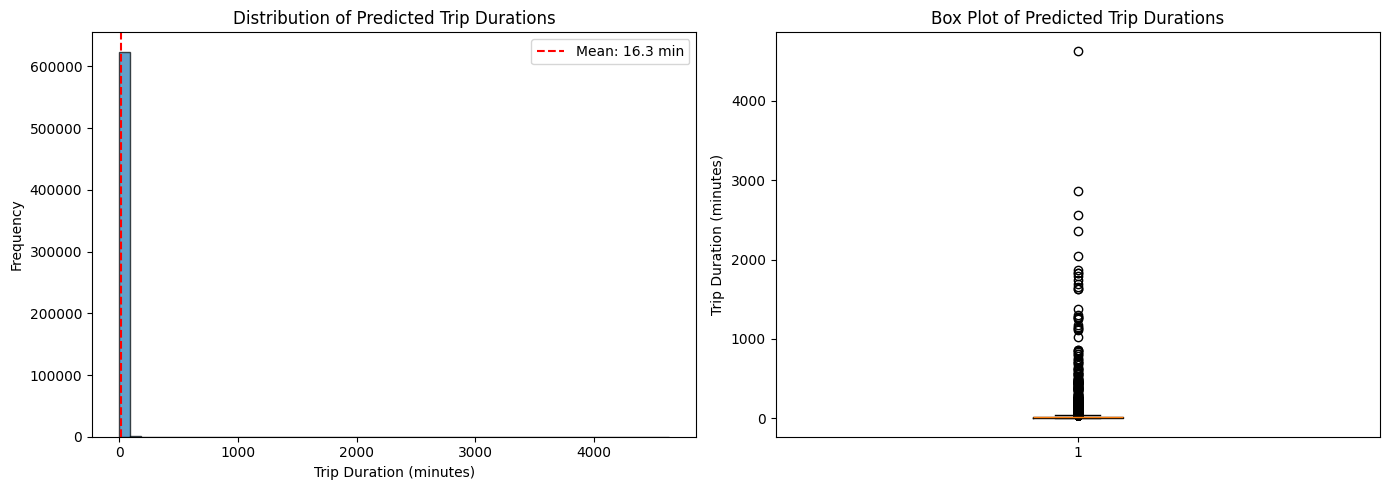

✓ Visualisations créées


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des prédictions
axes[0].hist(test_predictions / 60, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Trip Duration (minutes)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Predicted Trip Durations')
axes[0].axvline(test_predictions.mean()/60, color='r', linestyle='--', label=f'Mean: {test_predictions.mean()/60:.1f} min')
axes[0].legend()

# Box plot
axes[1].boxplot(test_predictions / 60)
axes[1].set_ylabel('Trip Duration (minutes)')
axes[1].set_title('Box Plot of Predicted Trip Durations')

plt.tight_layout()
plt.show()

print("✓ Visualisations créées")

## 6. Configuration du modèle utilisé

In [7]:
import yaml

# Charger la configuration
with open('../configs/config.yaml', 'r') as f:
    config = yaml.safe_load(f)

print("\n" + "="*60)
print("CONFIGURATION DU MODÈLE")
print("="*60)
print(f"\nAlgorithme: {config['training']['algorithm']}")
print(f"Nombre d'arbres: {config['training']['n_estimators']}")
print(f"Profondeur max: {config['training']['max_depth']}")
print(f"Min samples split: {config['training']['min_samples_split']}")
print(f"Min samples leaf: {config['training']['min_samples_leaf']}")
print(f"Random state: {config['training']['random_state']}")
print(f"\nFichier du modèle: {config['model']['model_dir']}/{config['model']['model_name']}")


CONFIGURATION DU MODÈLE

Algorithme: random_forest
Nombre d'arbres: 100
Profondeur max: 20
Min samples split: 5
Min samples leaf: 2
Random state: 42

Fichier du modèle: models/taxi_model.pkl
